In [23]:
# Copyright (c) TorchGeo Contributors. All rights reserved.
# Licensed under the MIT License.

# Tessera Embeddings

_Written by: Simone De Gasperis_

# Introduction

In this notebook we will see how to use Tessera Embeddings for crop classification.
We will use CDL layer (Cropland Data Layer), https://www.nass.usda.gov/Research_and_Science/Cropland/sarsfaqs2.php, that provides a raster, geo-referenced, crop-specific land cover map for the continental United States and TESSERA embeddings.

While a standard satellite image pixel just tells you the color or light intensity at a point, a GeoTessera embedding packs a year's worth of information, like how vegetation grows or how the ground moisture changes over time into a single mathematical signature.

Every crop has a unique phenological cycle: the timing of when it is planted, when it greens up, when it flowers, and when it is harvested.
In a traditional approach, you would have to manually process dozens of satellite images from throughout the year to see these changes.
Yearly embeddings from foundation models like TESSERA "digests" the entire year of observations. They compress seasonal signals into a fixed-length vector.

In this notebook we will train a lightweight neural network for pixel-wise classification (crop type detection) from the embeddings.

# Environment

For the environment, we will install the torchgeo as well as other standard libraries and scikit-learn packages.

In [24]:
# Install scikit-learn
!pip install -U scikit-learn
!pip install -q huggingface_hub
!pip install tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


# Imports

In [25]:
from pathlib import Path

import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import snapshot_download
from lightning.pytorch import Trainer
from matplotlib.patches import Patch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
)
from torch import nn
from torchmetrics import Accuracy

from torchgeo.datamodules.tessera_cdl_datamodule import TesseraCDLDataModule

# Dataset

GeoTessera embeddings can be downloaded easily thanks to geotessera library.
In this notebook we will use a small sample on HF but you can download a larger one thank to geotessera library.

For this tutorial I'm considering 2 contigous areas in the US for train and validation.

We will only consider main classes represented in this small sample data, other classes will be remapped to a common value.

According to CDL these are:
- 1: Corn
- 5: Soybeans
- 36: Alfalfa

We will ignore other classes and map them to 0

In [26]:
# Download the dataset from Hugging Face and load train/val embeds
repo_id = 'torchgeo/tessera_sample'
cache_root = Path('/tmp/tessera_sample')

if not cache_root.exists():
    cache_root.mkdir(parents=True, exist_ok=True)

print(f'Downloading {repo_id} into {cache_root} (may take a few minutes)...')
repo_path = Path(
    snapshot_download(repo_id=repo_id, cache_dir=str(cache_root), repo_type='dataset')
)

train_dir = repo_path / 'train' / 'global_0.1_degree_representation' / '2024'
val_dir = repo_path / 'val' / 'global_0.1_degree_representation' / '2024'

print(f'Train dir: {train_dir}')
print(f'Val dir:   {val_dir}')

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Train dir: /tmp/tessera_sample/datasets--torchgeo--tessera_sample/snapshots/623c3681bf4fafe385fbca4c51f596bc0ae85e96/train/global_0.1_degree_representation/2024
Val dir:   /tmp/tessera_sample/datasets--torchgeo--tessera_sample/snapshots/623c3681bf4fafe385fbca4c51f596bc0ae85e96/val/global_0.1_degree_representation/2024


In [27]:
# NOTE: If you want to use the tessera embeddings for another area you can use the following commands.

# 1) Install geotessera package in your env.
# pip install geotessera

# 2 ) download train data, from command line use:
# geotessera download --bbox "-94.7, 40.7, -94.8, 40.8" --year 2024 --output ./tessera_sample --format tiff

# 3) download val data
# geotessera download --bbox "-94.85, 40.8, -94.8, 40.85" --year 2024 --output ./tessera_sample_val --format tiff

# 4) put the data at the same level of this notebook and define the repo_path variable with the path to the data

In [28]:
CLASSES_TO_CONSIDER = [0, 1, 5, 36]

datamodule = TesseraCDLDataModule(
    data_dir='./data',
    tessera_root=repo_path,
    year=2024,
    classes=CLASSES_TO_CONSIDER,
    patch_size=32,
    num_train_patches=800,
    batch_size=64,
    num_workers=4,
)

datamodule.setup('fit')

Converting TesseraEmbeddings CRS from PROJCRS["WGS 84 / UTM zone 15N",BASEGEOGCRS["WGS 84",DATUM["World Geodetic System 1984",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 15N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-93,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",32615]] to PROJCRS["NAD83 / Conus Albers",BASEGEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIP

In [29]:
train_loader = datamodule.train_dataloader()
val_loader = datamodule.val_dataloader()

In [30]:
# check bounds
print('train:', datamodule.train_dataset.bounds)
print('val:', datamodule.val_dataset.bounds)

train: (slice(np.float64(91807.27385615245), np.float64(117511.73883235462), 30.0), slice(np.float64(1965748.2128468328), np.float64(1977617.3136997432), 30.0), slice(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-12-31 23:59:59.999999'), 1))
val: (slice(np.float64(83427.27950060501), np.float64(92414.1222640539), 30.0), slice(np.float64(1965645.654295221), np.float64(1977316.295062596), 30.0), slice(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-12-31 23:59:59.999999'), 1))


In [31]:
len(datamodule.train_dataset), len(datamodule.val_dataset)

(3, 1)

In [32]:
# Number of train patches
len(datamodule.train_sampler)

800

In [33]:
# Number of val patches
len(datamodule.val_sampler)

130

Geotessera embeddings are 128-dimensional vectors therefore for plotting torchgeo implements PCA to reduce to just 3 dimensions.
Pixels with similar features will have similar colors.

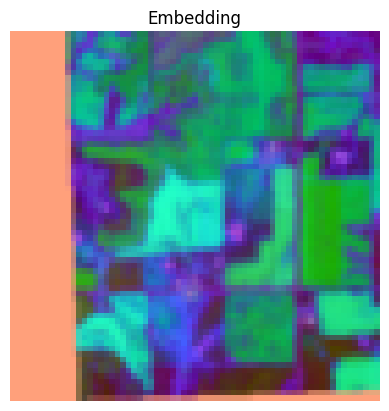

In [34]:
# plot a small part
x_slice, y_slice, t_slice = datamodule.train_dataset.bounds

minx, maxx = x_slice.start, x_slice.stop
miny, maxy = y_slice.start, y_slice.stop
mint, maxt = t_slice.start, t_slice.stop

width = 2000
height = 2000

small_region = (
    slice(minx, minx + width),
    slice(miny, miny + height),
    slice(mint, maxt),
)

sample = datamodule.train_dataset[small_region]
datamodule.train_dataset.datasets[1].plot(sample);  # suppress auto-display

Let's check crs and resolution of train and val set

In [35]:
datamodule.train_dataset.res

(30.0, 30.0)

In [36]:
datamodule.train_dataset.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

# Model

We will train a small model to do pixelwise classification. Embeddings compress seasonal signals into a fixed-length vector allowing to train small model for downstream tasks.

In [37]:
class TesseraClassifier(pl.LightningModule):
    def __init__(
        self, input_dim=128, num_classes=50, hidden_dim=32, learning_rate=0.001
    ):
        super().__init__()
        self.save_hyperparameters()

        # Model
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes),
        )

        # Loss and metrics
        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_accuracy = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        embeddings = batch['embeddings']  # Shape: (batch_size, input_dim)
        labels = batch['labels']  # Shape: (batch_size,)

        logits = self(embeddings)
        loss = self.criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)
        self.train_accuracy(preds, labels)

        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.train_accuracy, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        embeddings = batch['embeddings']
        labels = batch['labels']

        logits = self(embeddings)
        loss = self.criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)
        self.val_accuracy(preds, labels)

        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_accuracy, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_acc',
                'interval': 'epoch',
                'frequency': 1,
            },
        }

# Training

In [38]:
# Get num of classes from cdl layer
num_classes = len(datamodule.train_dataset.datasets[0].classes)

# Create model
model = TesseraClassifier(
    input_dim=128,  # Tessera embeddings are 128-dimensional
    num_classes=num_classes,
    hidden_dim=32,
    learning_rate=0.001,
)

# Train with Lightning
trainer = Trainer(
    max_epochs=1,  # Adjust as needed, limited to 1 for demonstration
    accelerator='auto',  # Uses GPU if available
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            monitor='val_acc',
            mode='max',
            save_top_k=1,
            filename='best-{epoch:02d}-{val_acc:.2f}',
        )
    ],
)

trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Converting TesseraEmbeddings CRS from PROJCRS["WGS 84 / UTM zone 15N",BASEGEOGCRS["WGS 84",DATUM["World Geodetic System 1984",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 15N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-93,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,2],AXIS["easting",east,ORDER[1],LENGTHUNIT["metre",1]],AXIS["northing",north,ORDER[2],LENGTHUNIT["metre",1]],ID["EPSG",32615]] to PROJCRS["NAD83 / Conus Albers",BASEGEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIP

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model          │ Sequential         │  4.7 K │ train │     0 │
│ 1 │ criterion      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 4.7 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.7 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/simone/.pyenv/versions/torchgeo/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/simone/.pyenv/versions/torchgeo/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The 
number of training batches (12) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower 
value for log_every_n_steps if you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=1` reached.


In [39]:
# save the model
torch.save(model.state_dict(), 'model.pth')

# Evaluation

For pixel-wise classification tasks like crop detection from satellite imagery, we use a comprehensive set of metrics to evaluate model performance:

The metrics considered are:

1. **Overall Accuracy**: Percentage of correctly classified pixels across all classes. Provides a quick overview but can be misleading with imbalanced datasets.

2. **Per-Class Precision, Recall, and F1-Score**: These metrics from the classification report show how well the model performs for each individual crop class, accounting for class imbalance.

3. **Cohen's Kappa**: Measures agreement between predicted and true labels while accounting for chance agreement. Better than raw accuracy for imbalanced datasets. Values > 0.6 indicate good agreement.

4. **Confusion Matrix**: Shows which classes are confused with each other. Particularly useful for understanding if similar crops (e.g., corn vs soybeans) are being confused.

In [40]:
def load_model(checkpoint_path='best_model.pth', num_classes=None, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f'Loading model on device: {device}')
    ckpt = torch.load(checkpoint_path, map_location=device)

    model = TesseraClassifier(input_dim=128, hidden_dim=32, num_classes=num_classes).to(
        device
    )

    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
    else:
        model.load_state_dict(ckpt)

    model.eval()

    return model


def evaluate_model(checkpoint_path, val_dataloader, save_plot=True, device=None):
    import matplotlib.pyplot as plt
    import torch

    # Device
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Get classes from dataloader dataset
    val_dataset = val_dataloader.dataset

    if hasattr(val_dataset, 'datasets'):
        cdl_dataset = next(d for d in val_dataset.datasets if hasattr(d, 'classes'))
    else:
        cdl_dataset = val_dataset

    CLASSES_TO_CONSIDER = cdl_dataset.classes
    num_classes = len(CLASSES_TO_CONSIDER)

    # Load model
    model = load_model(checkpoint_path, num_classes=num_classes)
    model.to(device)
    model.eval()

    # Evaluation loop
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_dataloader:
            x = batch['embeddings'].to(device)
            y = batch['labels'].to(device)

            if x.size(0) == 0:
                continue

            logits = model(x)
            preds = logits.argmax(dim=1)

            y_true.append(y.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    # Flatten
    y_true = np.concatenate(y_true) if len(y_true) else np.array([])
    y_pred = np.concatenate(y_pred) if len(y_pred) else np.array([])

    if len(y_true) == 0:
        print('No valid pixels found for evaluation.')
        return [], []

    # Metrics
    labels = np.arange(num_classes)
    target_names = [str(cls) for cls in CLASSES_TO_CONSIDER]

    print('\nClassification Report\n')
    print(
        classification_report(
            y_true,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4,
            zero_division=0,
        )
    )

    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f'Overall Accuracy: {acc:.4f}')
    print(f"Cohen's Kappa:    {kappa:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-7)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Proportion (Recall)')

    tick_marks = np.arange(num_classes)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(target_names, rotation=45, ha='right')
    ax.set_yticklabels(target_names)

    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')
    ax.set_title('Normalized Confusion Matrix')

    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(
                j,
                i,
                f'{cm_norm[i, j]:.2f}',
                ha='center',
                va='center',
                color='white' if cm_norm[i, j] > 0.5 else 'black',
                fontsize=9,
            )

    plt.tight_layout()

    if save_plot:
        plt.savefig('confusion_matrix_normalized.png', dpi=150)

    plt.show()

    return y_true, y_pred

Loading model on device: cuda

Classification Report

              precision    recall  f1-score   support

           0     0.7957    0.9086    0.8484     70019
           1     0.7577    0.7851    0.7712     28454
           5     0.9439    0.6768    0.7883     33032
          36     0.0000    0.0000    0.0000      1615

    accuracy                         0.8137    133120
   macro avg     0.6243    0.5926    0.6020    133120
weighted avg     0.8147    0.8137    0.8067    133120

Overall Accuracy: 0.8137
Cohen's Kappa:    0.6856


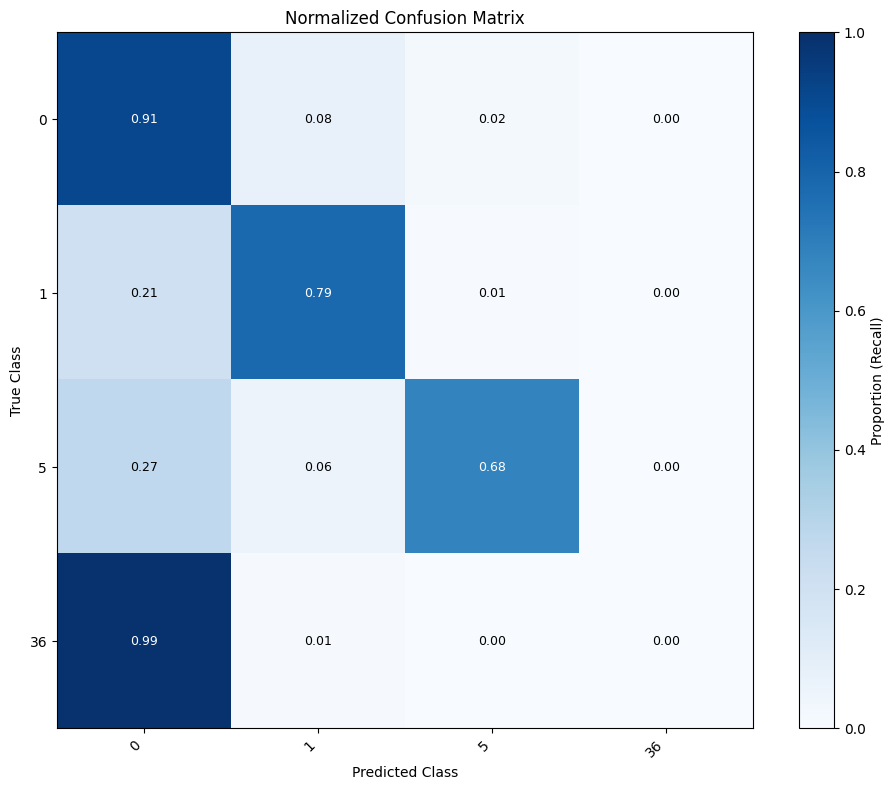

In [41]:
results = evaluate_model(checkpoint_path='model.pth', val_dataloader=val_loader)

# Results Quality Assessment


The model achieves good pixel-wise accuracy and good Cohen's Kappa indicating **substantial agreement** between predictions and ground truth. For a pixel-level crop classification task, this is a good result. For demonstrative purposes a lightweight model was used and it was trained for a few epochs but performances could be improved by changing these parameters.

We have:

1. **Good crop classification**: The main agricultural crops perform very well

2. **Balanced performance**: Good precision-recall balance across main classes indicates the model isn't overfitting to common classes.

3. **Lightweight model**: the model is efficient while achieving competitive accuracy. This demonstrates the power of TESSERA embeddings. A year's worth of phenological information in 128 dimensions captures crop characteristics remarkably well.

For the challenges:

1. **Minority class struggle**: 
   - **AlfaAlfa (Class 36)**: Lower performance despite being a target class

2. **Class imbalance effects**:
   - No data (no data + the remapped other classes) dominates training data, potentially biasing the model


Regarding possible improvements.

We have used a random sampling for creating the train data loaders but we could implement a more advanced approach.
We could use a for instance a weighted approach to deal with underepresented classes.
We could increase the number of samples in the training dataset.

# Prediction visualization

In this section we will graphically observe the mask vs predictions for a random sample from the val dataset.

In [42]:
def visualize_nn_predictions(
    checkpoint_path, dataset, region_size=1000, batch_size=50000
):
    """Visualize predictions vs ground truth"""

    #  Get underlying CDL dataset
    cdl_dataset = next(d for d in dataset.datasets if hasattr(d, 'classes'))
    num_classes = len(cdl_dataset.classes)

    #  Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model(checkpoint_path, num_classes=num_classes).to(device).eval()

    #  Extract region
    bounds = dataset.bounds
    minx = bounds[0].start if isinstance(bounds[0], slice) else bounds[0]
    miny = bounds[1].start if isinstance(bounds[1], slice) else bounds[2]

    sample = dataset[(slice(minx, minx + region_size), slice(miny, miny + region_size))]

    image = sample['image'].numpy()
    mask = sample['mask'].squeeze().numpy()
    C, H, W = image.shape

    #  Predict (batched)
    X = torch.from_numpy(image.transpose(1, 2, 0).reshape(-1, C)).float()

    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            logits = model(X[i : i + batch_size].to(device))
            preds.append(logits.argmax(1).cpu())

    predictions = torch.cat(preds).reshape(H, W)

    #  Accuracy
    mask_t = torch.from_numpy(mask)
    valid = mask_t >= 0
    acc = (predictions[valid] == mask_t[valid]).float().mean().item()

    #  Use CDL plot
    sample['prediction'] = predictions
    fig = cdl_dataset.plot(sample, suptitle=f'Accuracy: {acc:.2%}')
    fig.set_size_inches(16, 6)

    ax = fig.axes[0]
    add_cdl_legend(ax, cdl_dataset)

    plt.show()

    return predictions.numpy(), mask


def add_cdl_legend(ax, cdl_dataset, max_classes=10):
    """Add a legend using CDL colors."""

    handles = []

    # Limit number of classes
    classes = cdl_dataset.classes[:max_classes]

    for c in classes:
        color = cdl_dataset.cmap(c)
        handles.append(Patch(color=color, label=f'Class {c}'))

    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.0,
        fontsize=12,
    )

In [43]:
val_dataset = datamodule.val_dataset

Loading model on device: cuda


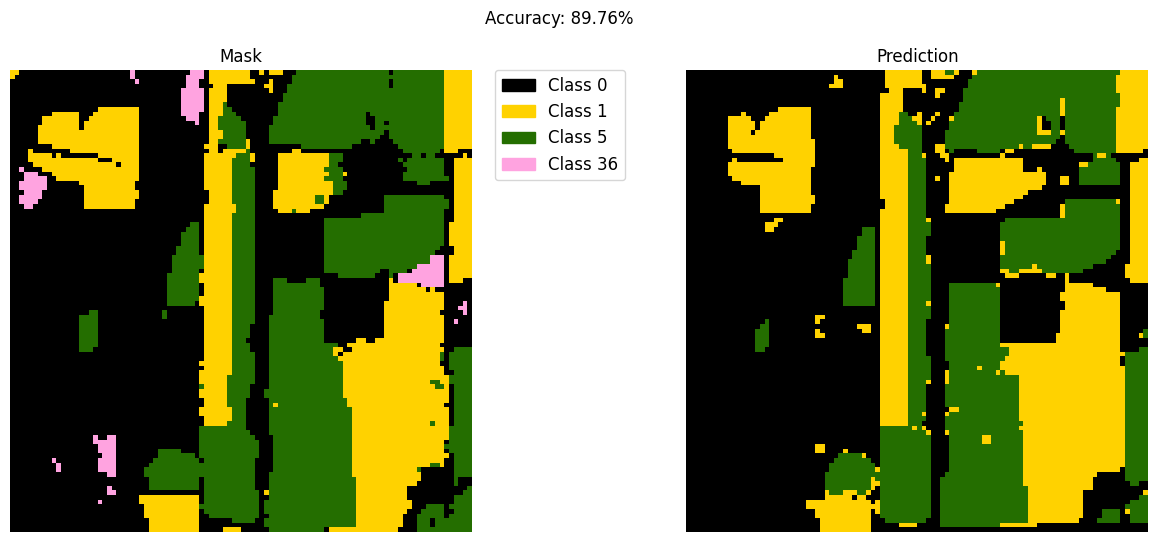

In [44]:
visualize_nn_predictions(
    checkpoint_path='model.pth', dataset=val_dataset, region_size=3000
);

# Additional reading

- TESSERA: Temporal Embeddings of Surface Spectra for Earth Representation and Analysis  
arXiv:2506.20380,  https://arxiv.org/abs/2506.20380


- Official documentation about Crop Data Layer can be found at: https://www.nass.usda.gov/Research_and_Science/Cropland/metadata/meta.php
